In [3]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
features = pd.read_csv("../data/features.csv")
stores = pd.read_csv("../data/stores.csv")

print(train.shape)
print(features.shape)
print(stores.shape)

(421570, 5)
(8190, 12)
(45, 3)


In [4]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  str    
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), str(1)
memory usage: 17.3 MB


In [6]:
features.info()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 791.9 KB


In [7]:
stores.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [8]:
train["Store"].nunique(), train["Dept"].nunique()

(45, 81)

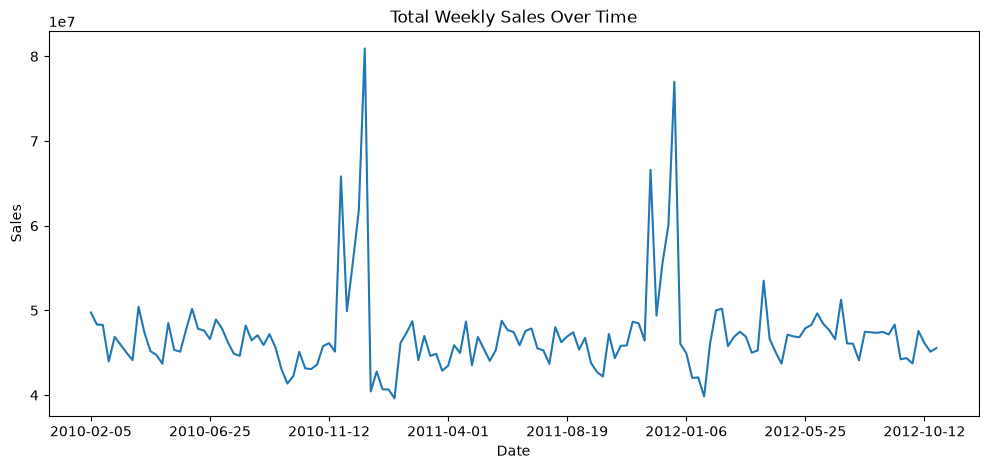

In [9]:
sales = train.groupby("Date")["Weekly_Sales"].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sales.plot()
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [10]:
train.groupby("IsHoliday")["Weekly_Sales"].mean()

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

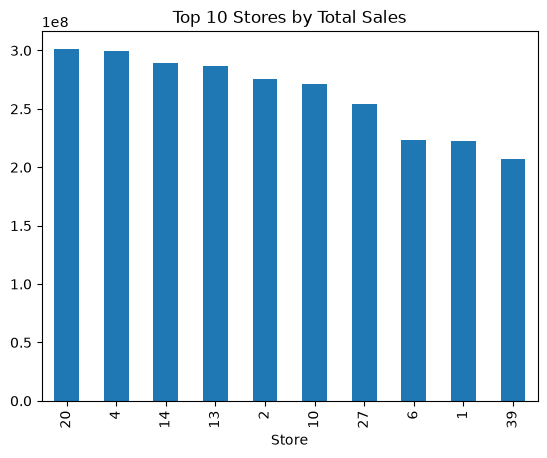

In [11]:
top_stores = (
    train.groupby("Store")["Weekly_Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_stores.head(10).plot(kind="bar")
plt.title("Top 10 Stores by Total Sales")
plt.show()

In [12]:
features.info()
features.head()

<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 791.9 KB


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [13]:
df = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

df = df.merge(
    stores,
    on="Store",
    how="left"
)

df.shape

(421570, 16)

In [14]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [15]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

df["Quarter"] = df["Date"].dt.quarter

In [16]:
df[
    [
        "Date",
        "Year",
        "Month",
        "Week",
        "Quarter"
    ]
].head()

,Date,Year,Month,Week,Quarter
0,2010-02-05,2010,2,5,1
1,2010-02-12,2010,2,6,1
2,2010-02-19,2010,2,7,1
3,2010-02-26,2010,2,8,1
4,2010-03-05,2010,3,9,1


In [17]:
df = df.sort_values(
    ["Store", "Dept", "Date"]
)

In [18]:
#lag 1 week
df["Lag_1"] = (
    df.groupby(["Store", "Dept"])
      ["Weekly_Sales"]
      .shift(1)
)

In [19]:
#lag 4 weeks
df["Lag_4"] = (
    df.groupby(["Store", "Dept"])
      ["Weekly_Sales"]
      .shift(4)
)

In [20]:
#rolling mean
df["Rolling_Mean_4"] = (
    df.groupby(["Store", "Dept"])
      ["Weekly_Sales"]
      .transform(
          lambda x: x.shift(1)
                     .rolling(4)
                     .mean()
      )
)

In [21]:
df[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "Lag_1",
        "Lag_4",
        "Rolling_Mean_4"
    ]
].head(15)

,Store,Dept,Date,Weekly_Sales,Lag_1,Lag_4,Rolling_Mean_4
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,NaN,NaN
3,1,1,2010-02-26,19403.54,41595.55,NaN,NaN
4,1,1,2010-03-05,21827.90,19403.54,24924.50,32990.7700
5,1,1,2010-03-12,21043.39,21827.90,46039.49,32216.6200
6,1,1,2010-03-19,22136.64,21043.39,41595.55,25967.5950
7,1,1,2010-03-26,26229.21,22136.64,19403.54,21102.8675
8,1,1,2010-04-02,57258.43,26229.21,21827.90,22809.2850
9,1,1,2010-04-09,42960.91,57258.43,21043.39,31666.9175


In [22]:
model_df = df.dropna().copy()

In [23]:
features = [
    "Store",
    "Dept",
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Size",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "Lag_1",
    "Lag_4",
    "Rolling_Mean_4"
]

In [24]:
model_df = pd.get_dummies(
    model_df,
    columns=["Type"],
    drop_first=True
)

In [25]:
features.extend(["Type_B", "Type_C"])

In [26]:
X = model_df[features]
y = model_df["Weekly_Sales"]

In [27]:
split_date = "2012-01-01"

train_data = model_df[
    model_df["Date"] < split_date
]

test_data = model_df[
    model_df["Date"] >= split_date
]

In [28]:
X_train = train_data[features]
y_train = train_data["Weekly_Sales"]

X_test = test_data[features]
y_test = test_data["Weekly_Sales"]

In [29]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [30]:
preds = model.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, preds)

print("MAE:", mae)

MAE: 3940.885103562272


In [32]:
from sklearn.metrics import r2_score

print("R2:", r2_score(y_test, preds))

R2: 0.5491785382528567


In [33]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
14,Rolling_Mean_4,0.630370
13,Lag_4,0.123014
2,IsHoliday,0.054861
9,Month,0.054226
12,Lag_1,0.044163
10,Week,0.024278
4,Fuel_Price,0.023062
1,Dept,0.021128
5,CPI,0.007313
6,Unemployment,0.004209


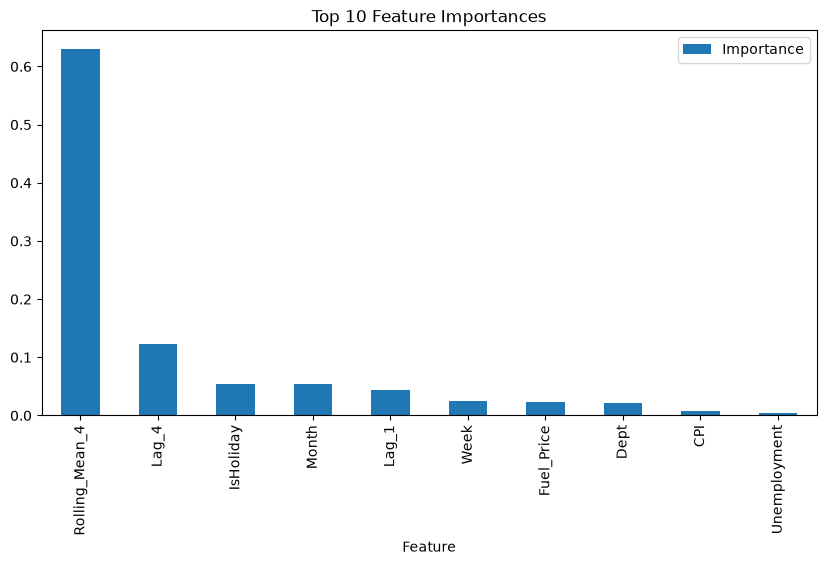

In [34]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Feature Importances")
plt.show()

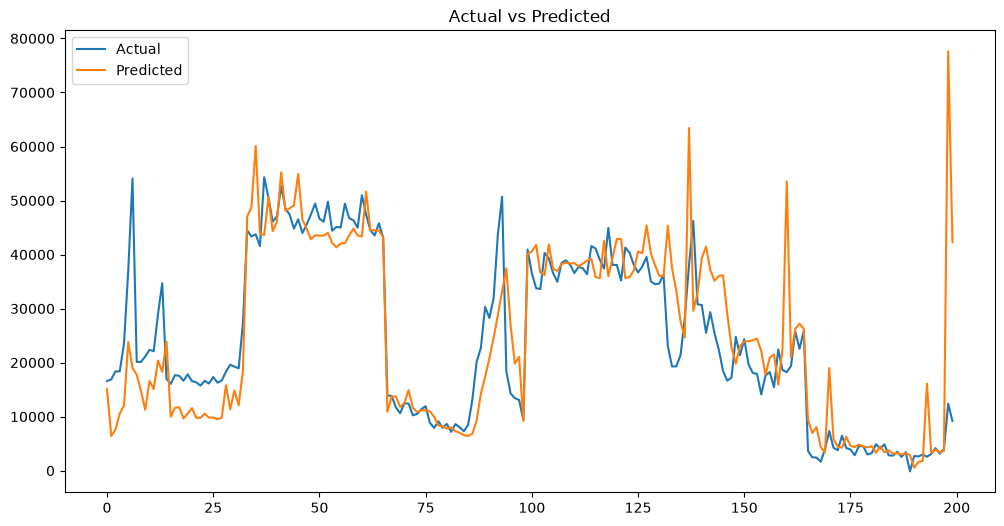

In [35]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    preds[:200],
    label="Predicted"
)

plt.legend()
plt.title("Actual vs Predicted")
plt.show()

## Data Cleaning

In [36]:
# Missing values in descending order
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

MarkDown2         310322
MarkDown4         286603
MarkDown3         284479
MarkDown1         270889
MarkDown5         270138
Lag_4              13134
Rolling_Mean_4     13134
Lag_1               3331
Fuel_Price             0
IsHoliday              0
Temperature            0
Date                   0
Dept                   0
Store                  0
Weekly_Sales           0
Type                   0
Unemployment           0
CPI                    0
Size                   0
Week                   0
Month                  0
Year                   0
Quarter                0
dtype: int64

## Handling Missing Values

In [37]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = df[markdown_cols].fillna(0)

In [38]:
df[markdown_cols].isnull().sum()

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64

In [39]:
df.isnull().sum().sort_values(ascending=False)

Rolling_Mean_4    13134
Lag_4             13134
Lag_1              3331
Weekly_Sales          0
Store                 0
Dept                  0
Date                  0
Fuel_Price            0
Temperature           0
IsHoliday             0
MarkDown1             0
MarkDown5             0
MarkDown2             0
MarkDown3             0
MarkDown4             0
Type                  0
Unemployment          0
CPI                   0
Size                  0
Week                  0
Month                 0
Year                  0
Quarter               0
dtype: int64

In [40]:
# 8-week lag
df["Lag_8"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .shift(8)
)

# 12-week lag
df["Lag_12"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .shift(12)
)

In [41]:
df["Rolling_Mean_8"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(8).mean())
)

df["Rolling_Mean_12"] = (
    df.groupby(["Store", "Dept"])["Weekly_Sales"]
      .transform(lambda x: x.shift(1).rolling(12).mean())
)

In [42]:
model_df_v2 = df.dropna().copy()
model_df_v2.shape

(382955, 27)

In [43]:
model_df_v2 = pd.get_dummies(
    model_df_v2,
    columns=["Type"],
    drop_first=True
)

In [44]:
model_df_v2.columns

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature',
       'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
       'MarkDown5', 'CPI', 'Unemployment', 'Size', 'Year', 'Month', 'Week',
       'Quarter', 'Lag_1', 'Lag_4', 'Rolling_Mean_4', 'Lag_8', 'Lag_12',
       'Rolling_Mean_8', 'Rolling_Mean_12', 'Type_B', 'Type_C'],
      dtype='str')

In [45]:
features_v2 = [
    "Store",
    "Dept",
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Size",
    "Year",
    "Month",
    "Week",
    "Quarter",

    "Lag_1",
    "Lag_4",
    "Lag_8",
    "Lag_12",

    "Rolling_Mean_4",
    "Rolling_Mean_8",
    "Rolling_Mean_12",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",

    "Type_B",
    "Type_C"
]

In [46]:
split_date = "2012-01-01"

train_data = model_df_v2[
    model_df_v2["Date"] < split_date
]

test_data = model_df_v2[
    model_df_v2["Date"] >= split_date
]

In [47]:
X_train = train_data[features_v2]
y_train = train_data["Weekly_Sales"]

X_test = test_data[features_v2]
y_test = test_data["Weekly_Sales"]

In [48]:
from xgboost import XGBRegressor

model_v2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_v2.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [49]:
preds_v2 = model_v2.predict(X_test)

In [50]:
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

mae_v2 = mean_absolute_error(
    y_test,
    preds_v2
)

r2_v2 = r2_score(
    y_test,
    preds_v2
)

print("MAE:", mae_v2)
print("R2 :", r2_v2)

MAE: 1454.2457711335003
R2 : 0.9803770394199716


In [51]:
print(train_data["Date"].min())
print(train_data["Date"].max())

print(test_data["Date"].min())
print(test_data["Date"].max())

2010-04-30 00:00:00
2011-12-30 00:00:00
2012-01-06 00:00:00
2012-10-26 00:00:00


In [52]:
print(len(train_data))
print(len(test_data))

256034
126921


In [53]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_v2.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

,Feature,Importance
16,Rolling_Mean_4,0.419869
12,Lag_1,0.352983
17,Rolling_Mean_8,0.065357
13,Lag_4,0.026235
2,IsHoliday,0.020153
21,MarkDown3,0.013225
10,Week,0.012420
9,Month,0.011086
18,Rolling_Mean_12,0.010644
14,Lag_8,0.006879


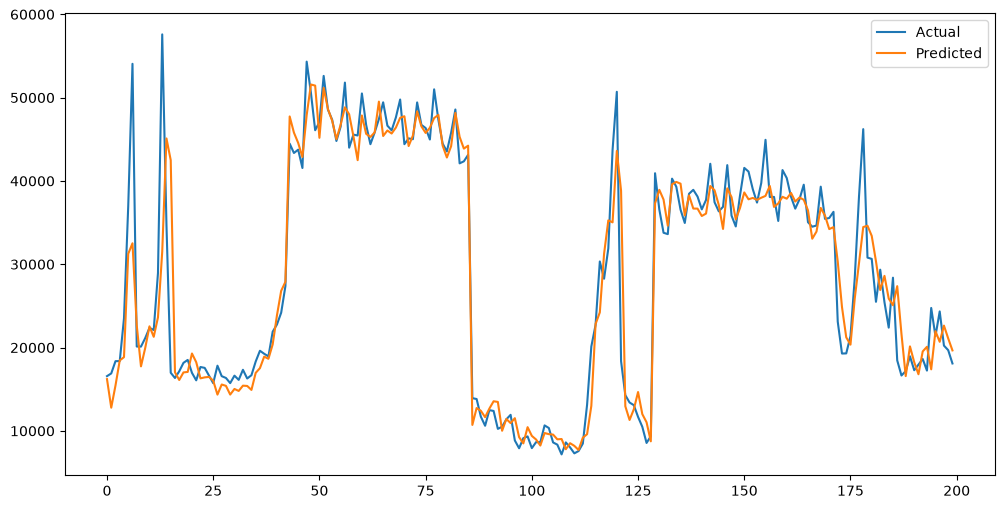

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(preds_v2[:200], label="Predicted")

plt.legend()
plt.show()

In [58]:
wmape = (
    abs(y_test - preds_v2).sum()
    / abs(y_test).sum()
)

print("WMAPE:", wmape)
print(f"WMAPE: {wmape*100:.2f}%")

WMAPE: 0.09228042507141147
WMAPE: 9.23%


In [56]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(
    y_test,
    preds_v2
)

print("RMSE:", rmse)

RMSE: 3101.814073409831


In [57]:
(y_test == 0).sum()
y_test.min()

np.float64(-1699.0)